Saved: fz_hysteresis_4edges_clean.png
Saved: fz_hysteresis_4edges_clean.svg


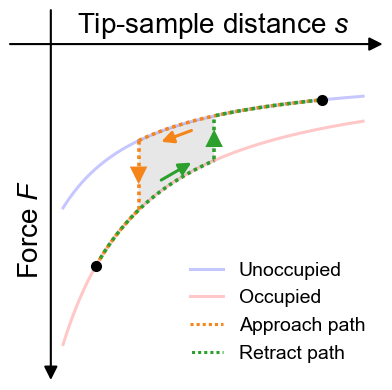

In [17]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon, Patch
from matplotlib.lines import Line2D
from matplotlib import font_manager


def set_font_prefer_arial():
    available = {f.name for f in font_manager.fontManager.ttflist}
    plt.rcParams["font.family"] = "Arial" if "Arial" in available else "DejaVu Sans"
    plt.rcParams["mathtext.fontset"] = "custom"
    plt.rcParams["mathtext.it"] = "Arial:italic"
    plt.rcParams["mathtext.rm"] = "Arial"


def electrostatic_force(z, strength=1.0, z0=0.8, p=1.3):
    z = np.asarray(z)
    return -strength / (z + z0) ** p


def plot_interval(ax, z, y, z1, z2, **kwargs):
    mask = (z >= z1) & (z <= z2)
    return ax.plot(z[mask], y[mask], **kwargs)


def add_arrow(ax, x1, y1, x2, y2, color, lw=2.2, ms=18, zorder=10, arrowstyle='-|>'):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle=arrowstyle,
            mutation_scale=ms,
            lw=lw,
            color=color,
            shrinkA=0,
            shrinkB=0,
            zorder=zorder,
            clip_on=False,
        )
    )


def add_triangle_marker(ax, x, y, direction, color, size=180, zorder=11):
    marker = {'up': '^', 'down': 'v', 'left': '<', 'right': '>'}[direction]
    ax.scatter([x], [y], s=size, marker=marker, c=[color], edgecolors='none',
               zorder=zorder, clip_on=False)


def add_curve_center_arrow(ax, x_start, x_end, yfunc, direction, color,
                           frac_inside=None, yother=None, lw=2.2, ms=18):
    xm = 0.5 * (x_start + x_end)
    dx = 0.2 * (x_end - x_start)

    xa, xb = xm - dx, xm + dx
    x1, x2 = (xb, xa) if direction < 0 else (xa, xb)

    y1, y2 = yfunc(x1), yfunc(x2)

    if frac_inside is not None and yother is not None:
        y1 = y1 - frac_inside * (y1 - yother(x1))
        y2 = y2 - frac_inside * (y2 - yother(x2))

    add_arrow(ax, x1, y1, x2, y2, color=color, lw=lw, ms=ms)


def main():
    set_font_prefer_arial()

    z_min = 0.15
    z_max = 7.5

    strength_weak = 0.7
    strength_strong = 1.4
    z0 = 2.5
    p = 1.28

    z_jump_left = 2.0
    z_jump_right = 3.85

    z_tip_bottom = 0.95
    z_tip_top = 6.5

    out_svg = "fz_hysteresis_4edges_clean.svg"
    out_png = "fz_hysteresis_4edges_clean.png"

    if not (z_min < z_tip_bottom < z_jump_left < z_jump_right < z_tip_top < z_max):
        raise ValueError(
            "Require z_min < z_tip_bottom < z_jump_left < z_jump_right < z_tip_top < z_max"
        )

    dash_app = (0, (1, 1))
    dash_ret = (1.5, (1, 1))

    fweak = lambda z: electrostatic_force(z, strength=strength_weak, z0=z0, p=p)
    fstrong = lambda z: electrostatic_force(z, strength=strength_strong, z0=z0, p=p)

    z_ref = np.linspace(z_min, z_max, 2000)
    Fw_ref = fweak(z_ref)
    Fs_ref = fstrong(z_ref)

    Fw_left = fweak(z_jump_left)
    Fs_left = fstrong(z_jump_left)
    Fw_right = fweak(z_jump_right)
    Fs_right = fstrong(z_jump_right)

    F_tip_top = fweak(z_tip_top)
    F_tip_bottom = fstrong(z_tip_bottom)

    z_loop = np.linspace(z_jump_left, z_jump_right, 500)
    poly_x = np.r_[
        z_loop,
        np.full(80, z_jump_right),
        z_loop[::-1],
        np.full(80, z_jump_left),
    ]
    poly_y = np.r_[
        fweak(z_loop),
        np.linspace(Fw_right, Fs_right, 80),
        fstrong(z_loop[::-1]),
        np.linspace(Fs_left, Fw_left, 80),
    ]

    c_weak = "#0004FF"
    c_strong = "#FF0202"
    c_app = "#F58518"
    c_ret = "#2CA02C"
    c_fill = "#BDBDBD"

    fig, ax = plt.subplots(figsize=(4, 4))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    plot_interval(ax, z_ref, Fw_ref, z_min, z_jump_left,
                  color=c_weak, lw=2.2, alpha=0.22)
    plot_interval(ax, z_ref, Fw_ref, z_jump_left, z_tip_top,
                  color=c_weak, lw=2.2, alpha=0.22)
    plot_interval(ax, z_ref, Fw_ref, z_tip_top, z_max,
                  color=c_weak, lw=2.2, alpha=0.22, label="Weak electrostatic force")

    plot_interval(ax, z_ref, Fs_ref, z_min, z_tip_bottom,
                  color=c_strong, lw=2.2, alpha=0.22)
    plot_interval(ax, z_ref, Fs_ref, z_tip_bottom, z_jump_right,
                  color=c_strong, lw=2.2, alpha=0.22)
    plot_interval(ax, z_ref, Fs_ref, z_jump_right, z_max,
                  color=c_strong, lw=2.2, alpha=0.22, label="Strong electrostatic force")

    ax.add_patch(
        Polygon(
            np.column_stack([poly_x, poly_y]),
            closed=True,
            facecolor=c_fill,
            edgecolor="none",
            alpha=0.35,
            zorder=0,
        )
    )

    # Approach = top weak branch + left jump + lower strong branch
    plot_interval(ax, z_ref, Fw_ref, z_jump_left, z_tip_top,
                color=c_app, lw=2.6, ls=dash_app, zorder=5, label="Approach path")
    ax.plot([z_jump_left, z_jump_left], [Fw_left, Fs_left],
            color=c_app, lw=2.6, ls=dash_app, zorder=5)
    
    plot_interval(ax, z_ref, Fs_ref, z_tip_bottom, z_jump_left,
              color=c_app, lw=2.6, ls=dash_app, zorder=5)
    
    plot_interval(ax, z_ref, Fs_ref, z_tip_bottom, z_jump_right,
                  color=c_ret, lw=2.6, ls=dash_ret, zorder=5, label="Retract path")
    ax.plot([z_jump_right, z_jump_right], [Fs_right, Fw_right],
            color=c_ret, lw=2.6, ls=dash_ret, zorder=5)
    plot_interval(ax, z_ref, Fw_ref, z_jump_right, z_tip_top,
                  color=c_ret, lw=2.6, ls=dash_ret, zorder=5)

    ax.plot(z_tip_bottom, F_tip_bottom, "o", ms=7, color="black", zorder=8)
    ax.plot(z_tip_top, F_tip_top, "o", ms=7, color="black", zorder=8)

    frac = 0.18
    add_curve_center_arrow(
        ax, z_jump_left, z_jump_right, yfunc=fweak, direction=-1,
        color=c_app, frac_inside=frac, yother=fstrong
    )

    bottom_inside = lambda x: fstrong(x) + frac * (fweak(x) - fstrong(x))
    add_curve_center_arrow(
        ax, z_jump_left, z_jump_right, yfunc=bottom_inside, direction=+1,
        color=c_ret
    )

    ymid_left = 0.5 * (Fw_left + Fs_left)
    ymid_right = 0.5 * (Fs_right + Fw_right)
    add_triangle_marker(ax, z_jump_left, ymid_left, 'down', c_app, size=160)
    add_triangle_marker(ax, z_jump_right, ymid_right, 'up', c_ret, size=160)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(length=0)

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ymin = min(Fs_ref.min(), Fw_ref.min()) * 1.08 - 0.02
    ymax = 0.06 - 0.02
    xmin = z_min - 0.3
    xmax = z_max + 0.48
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # --------------------------------
    # Custom axes: origin at upper-left
    # x-axis: rightward from (xmin, ymax)
    # y-axis: downward from (xmin, ymax)
    # --------------------------------
    origin = (xmin, ymax)

    # horizontal axis (top)
    add_arrow(ax, origin[0]-1.0, origin[1], xmax, origin[1],
              color='black', lw=1.5, ms=20, zorder=20)

    # vertical axis (downward)
    add_arrow(ax, origin[0], origin[1]+0.05, origin[0], ymin,
              color='black', lw=1.5, ms=20, zorder=20)

    # axis labels placed manually
    xr = xmax - xmin
    yr = ymax - ymin

    ax.text(
        xmin + 0.08 * xr, ymax + 0.01 * yr,
        r"Tip-sample distance $s$",
        fontsize=20,
        ha="left", va="bottom"
    )

    ax.text(
        xmin - 0.06 * xr, ymax - 0.55 * yr,
        r"Force $F$",
        fontsize=20,
        ha="center", va="center",
        rotation=90
    )

    legend_handles = [
        Line2D([0], [0], color=c_weak, lw=2.2, alpha=0.22, label="Unoccupied"),
        Line2D([0], [0], color=c_strong, lw=2.2, alpha=0.22, label="Occupied"),
        Line2D([0], [0], color=c_app, lw=2.2, ls=dash_app, label="Approach path"),
        Line2D([0], [0], color=c_ret, lw=2.2, ls=dash_ret, label="Retract path"),
        # Patch(facecolor=c_fill, edgecolor=c_fill, alpha=0.35, label="Hysteresis loop"),
    ]
    ax.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=14,
        loc="lower right",
        handlelength=1.7,
    )

    fig.tight_layout()
    fig.savefig(out_png, dpi=180, transparent=True)
    fig.savefig(out_svg, transparent=True)
    print(f"Saved: {out_png}")
    print(f"Saved: {out_svg}")


if __name__ == "__main__":
    main()